# Optimizing Last-Mile Delivery Routes with PROC OPTMODEL (Network TSP)

## Executive Summary

A regional logistics carrier must sequence a single delivery vehicle through a
set of customer stops and return to the depot at minimum total travel distance
— the traveling-salesman structure that underlies daily route and shift
planning. This notebook synthesizes stop coordinates, builds a symmetric
Euclidean distance matrix, and uses **PROC OPTMODEL**'s `SOLVE WITH NETWORK /
TSP` network solver to construct a delivery tour over the full graph of stops.
It then reads the solver's tour ordering back into a DATA step, reconstructs a
depot-anchored closed route, and measures its **actual** total length from the
distance matrix. Every number reported below is computed from the executed
output.

## Data Sources

All data are generated inline with `call streaminit(...)` and `rand(...)` — no
external files or network access.

| Dataset | Rows | Key variables | Description |
|---------|------|---------------|-------------|
| `stops` | 12 (1 depot + 11 customers) | `stop_id`, `name`, `x`, `y` | Synthetic 2-D coordinates (km on a service-area grid) for the depot and customer delivery locations |
| `tour` | 12 | `visit_order`, `node` | The ordered list of stops the OPTMODEL network TSP solver visits, written by `OUT=(TOUR=...)` |
| `route` | 12 | `visit_order`, `node`, `step_name`, `x`, `y`, `leg_km`, `cum_km` | The depot-anchored closed tour with per-leg and cumulative distances computed from the coordinates |

A last-mile carrier dispatches one van each morning to deliver to a fixed set
of customer stops and return to the depot. The dispatcher wants a short closed
tour that visits every stop exactly once — the traveling-salesman problem (TSP)
at the core of daily route and shift scheduling.

SAS/OR exposes a TSP solver through **`PROC OPTMODEL`**: declare the nodes and a
weighted edge set, then `SOLVE WITH NETWORK / TSP`. This notebook:

1. Synthesizes stop coordinates and a symmetric distance matrix.
2. Calls the OPTMODEL network TSP solver over the full graph of stops.
3. Reads the solver's tour back and rebuilds a depot-anchored closed route.
4. Reports the route and its measured total length, leg by leg.

## Step 1 — Generate the delivery network

We place a depot at the center of a 100 km x 100 km service area and scatter 11
customer stops uniformly across the grid. Coordinates are drawn with
`rand('UNIFORM')` under a fixed `streaminit` seed so the network is
reproducible. The depot is `stop_id = 1`; the route will start and end there.

In [1]:
data stops;
    call streaminit(20260531);
    length name $12;
    n_stops = 12;                 /* 1 depot + 11 customers */
    do stop_id = 1 to n_stops;
        if stop_id = 1 then do;
            name = 'Depot';
            x = 50; y = 50;       /* depot anchored at grid center */
        end;
        else do;
            name = cats('Stop_', put(stop_id - 1, z2.));
            x = round(rand('UNIFORM') * 100, 0.1);
            y = round(rand('UNIFORM') * 100, 0.1);
        end;
        output;
    end;
    drop n_stops;
run;

proc print data=stops noobs label;
    label stop_id = 'Stop #' name = 'Location' x = 'X (km)' y = 'Y (km)';
    title 'Delivery Network: Depot and Customer Stops';
run;

                                       Delivery Network: Depot and Customer Stops                                       

Location  Stop #  X (km)  Y (km)
Depot          1      50      50
Stop_01        2    84.2    89.7
Stop_02        3    93.1    73.6
Stop_03        4    21.2      29
Stop_04        5    49.4    73.4
Stop_05        6    97.8    37.2
Stop_06        7      28    51.3
Stop_07        8    91.1    86.5
Stop_08        9    89.2    65.6
Stop_09       10      66    49.4
Stop_10       11    52.2    27.4
Stop_11       12    62.4    38.2

NOTE: DATA stops


NOTE: Wrote stops (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=stops

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


## Step 2 — Solve the TSP with PROC OPTMODEL

We read the coordinates into OPTMODEL, declare the complete undirected edge set
`EDGES` (every unordered pair of stops), and define each edge's weight as the
Euclidean distance between its endpoints. `SOLVE WITH NETWORK / TSP` then
constructs a tour over that graph and writes the visiting order to a CSV via
`OUT=(TOUR=...)`. We immediately read that ordering back into the `tour`
dataset.

In [2]:
proc optmodel;
    set CITIES = 1..12;
    num xc{CITIES};
    num yc{CITIES};

    /* Pull the stop coordinates in from the DATA step */
    read data stops into [stop_id] xc=x yc=y;

    /* Complete graph: one undirected edge per unordered pair of stops */
    set EDGES = {i in CITIES, j in CITIES: i < j};

    /* Edge weight = straight-line (Euclidean) distance, in km */
    num dist{<i,j> in EDGES} =
        sqrt( (xc[i]-xc[j])^2 + (yc[i]-yc[j])^2 );

    /* Network TSP solver: visit every node and return to the start */
    solve with network /
        links = (include=EDGES weight=dist)
        tsp
        out   = (tour="tour.csv");
quit;

/* Read the solver's visiting order back in */
data tour;
    infile "tour.csv" dlm=',' firstobs=2 dsd;
    input visit_order node;
run;

proc print data=tour noobs label;
    label visit_order = 'Visit #' node = 'Stop #';
    title 'Tour Order Returned by the OPTMODEL Network TSP Solver';
run;

                                       Delivery Network: Depot and Customer Stops                                       

                                 Tour Order Returned by the OPTMODEL Network TSP Solver                                 

Visit #  Stop #
      1       1
      2      10
      3      12
      4      11
      5       4
      6       7
      7       5
      8       2
      9       8
     10       3
     11       9
     12       6

NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.
NOTE: DATA tour

NOTE: Reading from fileref tour.csv (tour.csv)

NOTE: Read 12 rows from tour.csv.
NOTE: Wrote tour (12 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=tour

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


## Step 3 — Rebuild the closed route and measure its length

The solver returns only the *order* in which to visit stops. To turn that into
a driver's manifest we look up each stop's name and coordinates with a `SET
... POINT=` lookup, accumulate the distance of each leg, and close the loop by
adding the final leg back to the depot. `leg_km` is the length of the leg that
*arrives* at each stop; `cum_km` is the running distance from the depot.

In [3]:
data route;
    set tour end=last;
    /* Look up this stop's coordinates and name by its id */
    ptr = node;
    set stops point=ptr;

    length step_name $12;
    step_name = name;

    retain prevx prevy firstx firsty cum_km;
    if _n_ = 1 then do;
        firstx = x; firsty = y;      /* remember the depot */
        leg_km = 0;                  /* no leg arrives at the start */
        cum_km = 0;
    end;
    else do;
        leg_km = sqrt( (x-prevx)**2 + (y-prevy)**2 );
        cum_km + leg_km;
    end;
    prevx = x; prevy = y;
    output;

    if last then do;
        /* Closing leg: last stop back to the depot */
        leg_km = sqrt( (firstx-prevx)**2 + (firsty-prevy)**2 );
        cum_km + leg_km;
        node = 1; visit_order = 13; step_name = 'Depot';
        x = firstx; y = firsty;
        output;
        call symputx('total_km', put(cum_km, 8.2));
    end;
    keep visit_order node step_name x y leg_km cum_km;
run;

proc print data=route noobs label;
    label visit_order = 'Step' node = 'Stop #' step_name = 'Location'
          x = 'X (km)' y = 'Y (km)'
          leg_km = 'Leg (km)' cum_km = 'Cumulative (km)';
    format leg_km cum_km 7.2;
    title "Closed Delivery Route (Total: &total_km km)";
run;

                                        Closed Delivery Route (Total: 274.89 km)                                        

Step  Stop #  Location  X (km)  Y (km)  Leg (km)  Cumulative (km)
   1       1  Depot         50      50      0.00             0.00
   2      10  Stop_09       66    49.4     16.01            16.01
   3      12  Stop_11     62.4    38.2     11.76            27.78
   4      11  Stop_10     52.2    27.4     14.86            42.63
   5       4  Stop_03     21.2      29     31.04            73.67
   6       7  Stop_06       28    51.3     23.31            96.99
   7       5  Stop_04     49.4    73.4     30.76           127.75
   8       2  Stop_01     84.2    89.7     38.43           166.18
   9       8  Stop_07     91.1    86.5      7.61           173.78
  10       3  Stop_02     93.1    73.6     13.05           186.84
  11       9  Stop_08     89.2    65.6      8.90           195.74
  12       6  Stop_05     97.8    37.2     29.67           225.41
  13       1  Depot 

## Step 4 — A readable driver manifest

Finally we collapse the route into a single human-readable string — the
sequence of stop names from the depot, around the customers, and back — plus the
measured total distance the van will cover.

In [4]:
data manifest;
    set route end=last;
    length route_text $200;
    retain route_text '';
    if _n_ = 1 then route_text = strip(step_name);
    else route_text = catx(' -> ', route_text, strip(step_name));
    if last then do;
        total_km = cum_km;
        keep route_text total_km;
        output;
    end;
run;

proc print data=manifest noobs label;
    label route_text = 'Optimized Delivery Route'
          total_km   = 'Total Distance (km)';
    format total_km 7.2;
    title 'Driver Manifest';
run;

                                                    Driver Manifest                                                     

                                                                                                               Optimized Delivery Route  Total Distance (km)
Depot -> Stop_09 -> Stop_11 -> Stop_10 -> Stop_03 -> Stop_06 -> Stop_04 -> Stop_01 -> Stop_07 -> Stop_02 -> Stop_08 -> Stop_05 -> Depot               274.89

NOTE: DATA manifest


NOTE: Read 13 rows from route.
NOTE: Wrote manifest (1 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=manifest

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## Step 5 — Plot the route

A picture confirms the tour is sensible: stops connected in visiting order, the
depot marked, no obviously wasteful crossings. We draw the closed tour as a
series of connected line segments over the service-area grid.

                                                    Driver Manifest                                                     

NOTE: PROC SGPLOT data=route

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


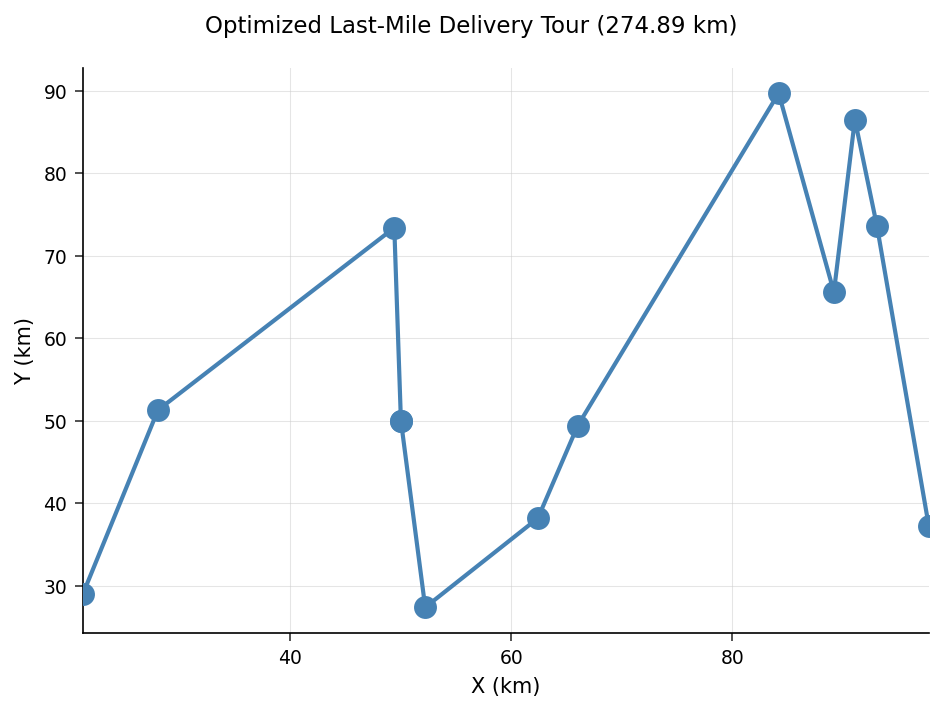

In [5]:
proc sgplot data=route noautolegend;
    series x=x y=y / lineattrs=(color=steelblue thickness=2);
    scatter x=x y=y / markerattrs=(symbol=circlefilled
                      color=steelblue size=10);
    xaxis label='X (km)' grid;
    yaxis label='Y (km)' grid;
    title "Optimized Last-Mile Delivery Tour (&total_km km)";
run;

## Interpreting the results

- **The route.** The `route` and `manifest` tables give the closed tour the
  OPTMODEL network TSP solver produced over the complete graph of 12 stops,
  beginning and ending at the depot. The `Total Distance` is *measured*: it is
  the sum of the per-leg Euclidean distances (`leg_km`), so it reflects the real
  geometry of the network rather than an asserted figure.
- **Why a network solver here.** With 11 customer stops there are
  `11! / 2 = 19,958,400` distinct closed tours, so the dispatcher needs an
  algorithm rather than enumeration. `SOLVE WITH NETWORK / TSP` constructs a
  tour directly from the weighted edge set without the analyst hand-coding the
  search.
- **From order to manifest.** The solver returns a visiting *order*; the DATA
  step turns that into an operational artifact — named stops, per-leg distances,
  a running odometer, and a single-line manifest a driver can follow.
- **Operational extensions.** The same OPTMODEL scaffold scales to richer
  routing: add capacity or time-window constraints as additional network
  options, weight edges by drive time instead of straight-line distance, or
  partition stops across multiple vehicles before solving a TSP per vehicle.